# Normal Execution

In [1]:
# Replace the failing notebook cell with this

import sys
from pathlib import Path

# Find project root (directory that contains "src")
cwd = Path.cwd().resolve()
project_root = next((p for p in [cwd, *cwd.parents] if (p / "src").exists()), None)

if project_root is None:
    raise ModuleNotFoundError("Could not locate project root containing a 'src' directory.")

# Ensure Python can import from project root
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [2]:
from typing import Literal, TypedDict

from dotenv import find_dotenv, load_dotenv
from IPython.display import Markdown, display
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_openai import ChatOpenAI
from langgraph.graph import END, START, StateGraph
from pydantic import BaseModel, Field

from src.scrappers.blog_posts_scrapper import BlogPostsScraper
from src.scrappers.social_media_scrapper import SocialMediaScraper
from src.scrappers.youtube_scrapper import YouTubeScrapper

In [3]:
load_dotenv(find_dotenv(), override=True)

True

In [4]:
OPENAI_MODEL = "gpt-5-mini"

In [5]:
class InputAnalyser(TypedDict):
    user_input: str
    analyse_output: str
    platforms: Literal['youtube', 'social_media', 'blog_posts', 'news_articles']

In [6]:
class PlatformRequired(BaseModel):
    analysis: str
    platform_needed: list[Literal['youtube', 'social_media', 'blog_posts', 'news_articles']] = Field(..., description="The values with which the the information can be extracted")

In [7]:
SYSTEM_PROMPT = """
Role: You are a powerful and intelligent examiner. 

Task: You will be given an input in the form of string and you will then analyse the input and provide your analysis about what the user is asking. 
After that you have to tell, from which platform the information can be extracted which can information about the user query.

There can be multiple platform from which the information can be extracted e.g blog sites, youtube videos.

You have below list of platform:
1. Youtube
2. Blog Post platform like Medium, Dev.to
3. Social media platform like Linkedin, X.com
4. News Article platform like Dainik Jagran (jagran.com), New York Times (nytimes.com)

Output: I need the final output which have 2 values:
1. Analysis: Your analysis about the user input query and why you have choose that or these platforms.
2. Platform Required: which can be single platform or a list of platform using which, information can be provided to the user
"""

In [8]:
def model_completion(system_prompt: str, user_prompt: str) -> PlatformRequired:

    llm = ChatOpenAI(model=OPENAI_MODEL, temperature=0)
    struct_llm = llm.with_structured_output(PlatformRequired)

    response = struct_llm.invoke(
        [
            SystemMessage(content=system_prompt),
            HumanMessage(content=user_prompt)
        ]
    )
    if isinstance(response, PlatformRequired):
        return response
    return PlatformRequired.model_validate(response)
    

In [11]:
def analyse_input(state: InputAnalyser):
    user_input = state['user_input']

    model_response = model_completion(system_prompt=SYSTEM_PROMPT, user_prompt=user_input)

    if user_input:
        return {'analyse_output': model_response.analysis, 'platforms': model_response.platform_needed}
    else:
        return {'analyse_output': "", 'platforms': None}

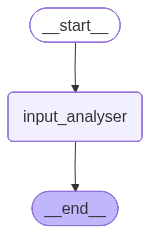

In [12]:
builder = StateGraph(InputAnalyser)
builder.add_node("input_analyser", analyse_input)
builder.add_edge(START, "input_analyser")
builder.add_edge("input_analyser", END)

graph = builder.compile()

graph

# Async Execution with Tools

#### With Tools

In [13]:
blog_posts_scraper = BlogPostsScraper()
youtube_scrapper = YouTubeScrapper()
social_media_scrapper = SocialMediaScraper()

2026-03-15 11:02:58,060 | blog_posts_scrapper.py:67 | INFO | Initialized BlogPostsScraper with Tavily client.
2026-03-15 11:02:58,063 | social_media_scrapper.py:52 | INFO | Initialized SocialMediaScraper (max_results=5, days=3).


In [14]:
class InputAnalyser(TypedDict):
    user_input: str
    analyse_output: str
    platforms: Literal['youtube', 'social_media', 'blog_posts', 'news_articles']

In [15]:
class PlatformRequired(BaseModel):
    analysis: str
    platform_needed: list[Literal['youtube', 'social_media', 'blog_posts', 'news_articles']] = Field(..., description="The values with which the the information can be extracted")

In [16]:
SYSTEM_PROMPT = """
Role: You are a powerful and intelligent examiner. 

Task: You will be given an input in the form of string and you will then analyse the input and provide your analysis about what the user is asking. 
After that you have to tell, from which platform the information can be extracted which can information about the user query.

There can be multiple platform from which the information can be extracted e.g blog sites, youtube videos.

You have below list of platform:
1. Youtube
2. Blog Post platform like Medium, Dev.to
3. Social media platform like Linkedin, X.com
4. News Article platform like Dainik Jagran (jagran.com), New York Times (nytimes.com)

Output: I need the final output which have 2 values:
1. Analysis: Your analysis about the user input query and why you have choose that or these platforms.
2. Platform Required: which can be single platform or a list of platform using which, information can be provided to the user
"""

In [17]:
async def async_model_completion(system_prompt: str, user_prompt: str) -> PlatformRequired:

    llm = ChatOpenAI(model=OPENAI_MODEL, temperature=0)
    struct_llm = llm.with_structured_output(PlatformRequired)

    response = await struct_llm.ainvoke(
        [
            SystemMessage(content=system_prompt),
            HumanMessage(content=user_prompt)
        ]
    )
    if isinstance(response, PlatformRequired):
        return response
    return PlatformRequired.model_validate(response)

In [ ]:
async def analyse_input(state: InputAnalyser) -> dict:
    user_input = state["user_input"]
    if not user_input:
        return {"analyse_output": "", "platforms": None}

    model_response = await async_model_completion(
        system_prompt=SYSTEM_PROMPT, user_prompt=user_input
    )

    if not model_response:
        return {"analyse_output": "", "platforms": None}

    if model_response:
        return {
            "analyse_output": model_response.analysis,
            "platforms": model_response.platform_needed,
        }
    else:
        return {}

In [ ]:
async def build_graph():
    builder = StateGraph(InputAnalyser)
    builder.add_node("input_analyser", analyse_input)
    builder.add_edge(START, "input_analyser")
    builder.add_edge("input_analyser", END)

    graph = builder.compile()

    return graph

In [ ]:
graph = await build_graph()
result = await graph.ainvoke(
        {
            "user_input": "Latest AI trends in 2024"
        }
    )

print(f"Result: {result}")

In [ ]:
await youtube_scrapper.get_transcripts_for_query(query="Latest AI trends in 2024")

In [ ]:
await blog_posts_scraper.search(topic="Latest AI trends in 2024")

In [ ]:
social_scrapped_results = await social_media_scrapper.fetch_social_pulse(topic="Latest AI trends in 2024")

In [ ]:
for result in social_scrapped_results:
    if result.source.lower() == "linkedin":
        print(result.url)
        display(Markdown(f"**LinkedIn Result:** {result.content}"))
        print("\n---\n")

In [ ]:
for result in social_scrapped_results:
    if result.source.lower() == "reddit":
        print(result.url)
        display(Markdown(f"**Reddit Result:** {result.content}"))

### Phase-2: Tool call, Summarization and Analysis

In [ ]:
# creating tool functions for each platform and then calling them in the graph based on the platform needed
from langchain_core.tools import tool
from langchain_core.utils.function_calling import convert_to_openai_tool

# 1. Define tools as normal Python functions — schema is auto-generated
#    from the function name, docstring, type hints, and annotations

@tool
async def search_youtube(query: str) -> list[dict]:
    """Search YouTube for videos and return transcripts related to the query."""
    return await youtube_scrapper.get_transcripts_for_query(query=query) # type:ignore

@tool
async def search_blog_posts(topic: str) -> list[dict]:
    """Search blog platforms like Medium and Dev.to for articles on the topic."""
    return await blog_posts_scraper.search(topic=topic) # type:ignore

@tool
async def search_social_media(topic: str) -> list[dict]:
    """Search social media platforms like LinkedIn and Reddit for posts on the topic."""
    return await social_media_scrapper.fetch_social_pulse(topic=topic) # type:ignore


# 2. Auto-convert to OpenAI/Groq-compatible tool schema — no manual JSON!
tools = [search_youtube, search_blog_posts, search_social_media]
openai_tools = [convert_to_openai_tool(t) for t in tools]

In [ ]:
async def async_model_completion_with_tools(system_prompt: str, user_prompt: str):
    llm = ChatOpenAI(model=OPENAI_MODEL, temperature=0)
    llm_with_tools = llm.bind_tools(openai_tools)

    response = await llm_with_tools.ainvoke(
        [
            SystemMessage(content=system_prompt),
            HumanMessage(content=user_prompt)
        ]
    )
    return response

In [ ]:
tool_system_prompt = (
        "You are a helpful assistant. Based on the user's query, call the appropriate "
        "search tools to gather information. You can call multiple tools if needed. "
        "Available tools search YouTube, blog posts, and social media."
    )

In [ ]:
result = await async_model_completion_with_tools(
    system_prompt=tool_system_prompt,
    user_prompt="Latest AI trends in 2024")

In [ ]:
result.tool_calls

In [ ]:

import json

from langchain_core.messages import AIMessage, HumanMessage, SystemMessage, ToolMessage
from langgraph.graph import END, START, MessagesState, StateGraph
from langgraph.prebuilt import ToolNode, tools_condition


# --- Small change 1: return the raw groq message object instead ---
async def async_model_completion_with_tools_v2(messages: list) -> AIMessage:
    """
    Same logic as before, but:
    - Accepts a messages list (so it fits LangGraph's MessagesState)
    - Converts Groq's native response → LangChain AIMessage
    That single conversion is all that is needed for LangGraph compatibility.
    """
    groq_client = await get_groq_client()

    chat_completion = await groq_client.chat.completions.create(
        messages=messages,
        # model="meta-llama/llama-4-maverick-17b-128e-instruct",
        model="moonshotai/kimi-k2-instruct-0905",
        temperature=0,
        tools=openai_tools,
        tool_choice="auto"
    )

    groq_msg = chat_completion.choices[0].message

    # --- Small change 2: convert Groq tool_calls → LangChain format ---
    lc_tool_calls = []
    if groq_msg.tool_calls:
        for tc in groq_msg.tool_calls:
            lc_tool_calls.append({
                "id": tc.id,
                "name": tc.function.name,
                "args": json.loads(tc.function.arguments),
                "type": "tool_call",
            })

    return AIMessage(content=groq_msg.content or "", tool_calls=lc_tool_calls)


# --- LangGraph node: wraps the function above ---
async def llm_node(state: MessagesState) -> dict:
    history = [{"role": "system", "content": tool_system_prompt}]
    for msg in state["messages"]:
        if isinstance(msg, HumanMessage):
            history.append({"role": "user", "content": msg.content})
        elif isinstance(msg, AIMessage):
            history.append({"role": "assistant", "content": msg.content or ""})
        elif isinstance(msg, ToolMessage):
            history.append({"role": "tool", "tool_call_id": msg.tool_call_id, "content": str(msg.content)})

    ai_message = await async_model_completion_with_tools_v2(history)
    return {"messages": [ai_message]}


# --- Wire up the graph using your existing @tool functions ---
tool_node = ToolNode(tools)   # tools = [search_youtube, search_blog_posts, search_social_media]

builder = StateGraph(MessagesState)
builder.add_node("llm", llm_node)
builder.add_node("tools", tool_node)

builder.add_edge(START, "llm")
builder.add_conditional_edges("llm", tools_condition)   # → "tools" if tool_calls present, else END
builder.add_edge("tools", "llm")                        # loop back after tools execute

agent_graph = builder.compile()
agent_graph


In [ ]:

# Run the graph
agent_result = await agent_graph.ainvoke({
    "messages": [HumanMessage(content="Latest AI trends in 2024")]
})

# Print the conversation flow
for msg in agent_result["messages"]:
    print(f"[{type(msg).__name__}]", msg.content[:200] if msg.content else f"tool_calls={[tc['name'] for tc in msg.tool_calls]}")


In [ ]:
async def llm_node(state: InputAnalyser) -> dict:
    response = await async_model_completion_with_tools(
        system_prompt=SYSTEM_PROMPT, user_prompt=state["user_input"]
    )
    return {
        "analyse_output": response.analysis,
        "platforms": response.platform_needed,
    }

In [ ]:
async def build_graph():

    tool_node = ToolNode(tools)

    builder = StateGraph(MessagesState)
    builder.add_node("llm", llm_node)
    builder.add_node("tools", tool_node)

    builder.add_edge(START, "llm")
    builder.add_conditional_edges("llm", tools_condition)  # → "tools" if tool_calls present, else END
    builder.add_edge("tools", "llm")                       # loop back after tools execute

    graph = builder.compile()
    return graph


In [ ]:
graph = await build_graph()
result = await graph.ainvoke({
    "messages": [HumanMessage(content="Latest AI trends in 2024")]
})

for msg in result["messages"]:
    if isinstance(msg, HumanMessage):
        print(f"[Human]: {msg.content}")
    elif isinstance(msg, AIMessage):
        if msg.tool_calls:
            print(f"[AI] → calling tools: {[tc['name'] for tc in msg.tool_calls]}")
        else:
            print(f"[AI]: {msg.content[:400]}")
    elif isinstance(msg, ToolMessage):
        print(f"[Tool - {msg.name}]: {str(msg.content)[:300]}")


### Phase-3: Sequential Pipeline — Analyse → Call Selected Tools → Summarize

In [ ]:
import asyncio
from typing import Annotated, TypedDict

from langgraph.graph import add_messages


class AgentState(TypedDict):
    messages: Annotated[list, add_messages]
    selected_platforms: list[str]
    scraped_results: dict[str, list]
    summary: str

In [ ]:
# Maps platform names (from PlatformRequired output) to scraper async callables
TOOL_REGISTRY: dict[str, dict] = {
    "youtube": {
        "fn": youtube_scrapper.get_transcripts_for_query,
        "param": "query",
    },
    "blog_posts": {
        "fn": blog_posts_scraper.search,
        "param": "topic",
    },
    "social_media": {
        "fn": social_media_scrapper.fetch_social_pulse,
        "param": "topic",
    },
}

In [ ]:
async def analyse_input_node(state: AgentState) -> dict:
    """Node 1: Analyse the user query and determine which platforms to scrape."""
    user_query = state["messages"][-1].content

    llm = ChatOpenAI(model=OPENAI_MODEL, temperature=0)
    struct_llm = llm.with_structured_output(PlatformRequired)

    response = await struct_llm.ainvoke(
        [
            SystemMessage(content=SYSTEM_PROMPT),
            HumanMessage(content=user_query),
        ]
    )

    if isinstance(response, PlatformRequired):
        platform_result = response
    else:
        platform_result = PlatformRequired.model_validate(response)

    print(f"[analyse_input] Platforms selected: {platform_result.platform_needed}")
    print(f"[analyse_input] Analysis: {platform_result.analysis}")

    return {"selected_platforms": platform_result.platform_needed}

In [ ]:
async def call_tools_node(state: AgentState) -> dict:
    """Node 2: Call only the scrapers for the selected platforms in parallel."""
    user_query = state["messages"][-1].content
    platforms = state["selected_platforms"]

    async def _call_scraper(platform: str) -> tuple[str, list]:
        entry = TOOL_REGISTRY.get(platform)
        if not entry:
            print(f"[call_tools] Skipping unknown platform: {platform}")
            return platform, []
        print(f"[call_tools] Calling scraper for: {platform}")
        result = await entry["fn"](**{entry["param"]: user_query})
        return platform, result

    results = await asyncio.gather(*[_call_scraper(p) for p in platforms])
    scraped = {platform: data for platform, data in results}

    print(f"[call_tools] Finished scraping: {list(scraped.keys())}")
    return {"scraped_results": scraped}

In [ ]:
SUMMARIZE_SYSTEM_PROMPT = """You are a research analyst. You will receive raw scraped data from multiple platforms \
(YouTube transcripts, blog posts, social media posts). Your job is to produce a single, \
well-structured summary that:

1. Preserves all key facts, names, dates, URLs, and statistics.
2. Organizes information by platform so the reader knows where each insight came from.
3. Highlights the most important and actionable findings.
4. Stays concise — aim for 800-1500 words maximum.
5. Omits boilerplate, duplicate information, and irrelevant noise.

This summary will be used for further downstream processing, so accuracy and completeness matter more than prose style."""


MAX_CHARS_PER_PLATFORM = 12000  # ~3k tokens per platform, safe for context window


async def summarize_node(state: AgentState) -> dict:
    """Node 3: Summarize all scraped results into a concise, structured summary."""
    user_query = state["messages"][-1].content
    scraped = state["scraped_results"]

    # Build per-platform content blocks, truncating if needed
    content_blocks = []
    for platform, data in scraped.items():
        raw_text = str(data)
        if len(raw_text) > MAX_CHARS_PER_PLATFORM:
            raw_text = raw_text[:MAX_CHARS_PER_PLATFORM] + "\n... [truncated]"
        content_blocks.append(f"=== {platform.upper()} ===\n{raw_text}")

    combined_content = "\n\n".join(content_blocks)

    user_message = (
        f"User query: {user_query}\n\n"
        f"Scraped data:\n{combined_content}\n\n"
        f"Please provide a structured summary of the above data."
    )

    llm = ChatOpenAI(model=OPENAI_MODEL, temperature=0)
    response = await llm.ainvoke(
        [
            SystemMessage(content=SUMMARIZE_SYSTEM_PROMPT),
            HumanMessage(content=user_message),
        ]
    )

    print(f"[summarize] Summary generated ({len(response.content)} chars)")
    return {"summary": response.content}

In [ ]:
# Build the sequential pipeline: analyse → call_tools → summarize
builder = StateGraph(AgentState)

builder.add_node("analyse_input", analyse_input_node)
builder.add_node("call_tools", call_tools_node)
builder.add_node("summarize", summarize_node)

builder.add_edge(START, "analyse_input")
builder.add_edge("analyse_input", "call_tools")
builder.add_edge("call_tools", "summarize")
builder.add_edge("summarize", END)

pipeline = builder.compile()
pipeline

In [ ]:
# Run the pipeline
pipeline_result = await pipeline.ainvoke(
    {"messages": [HumanMessage(content="Latest AI trends in 2024")]}
)

print("=" * 60)
print(f"Selected Platforms: {pipeline_result['selected_platforms']}")
print(f"Scraped Platforms:  {list(pipeline_result['scraped_results'].keys())}")
print("=" * 60)
print("\n--- SUMMARY ---\n")
display(Markdown(pipeline_result["summary"]))